INTEGRANTES:

Regina Espinosa

Andrea Santoyo

Jerónimo Rojas

In [1]:
!pip install --upgrade yfinance curl_cffi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/117.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 22.5 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.57
    Uninstalling yfinance-0.2.57:
      Successfully uninstalled yfinance-0.2.57


In [2]:
# Importar Librerías y Paqueterías necesarias:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
from curl_cffi import requests

In [39]:
ticker = 'MSFT'
data = yf.download(ticker, start='2022-01-01', end='2025-05-06')['Close']['MSFT']

[*********************100%***********************]  1 of 1 completed


In [40]:
data

,MSFT
Date,
2022-01-03,325.634766
2022-01-04,320.051086
2022-01-05,307.765015
2022-01-06,305.333069
2022-01-07,305.488678
...,...
2025-04-29,394.040009
2025-04-30,395.260010
2025-05-01,425.399994


In [41]:
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

In [42]:
session = requests.Session(impersonate="chrome")

In [43]:
msft = yf.Ticker("MSFT")
hist = msft.history(period="1y")
S0 = msft.history(period="1d")['Close'][0]
S0

<ipython-input-43-c2506ebf3102>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S0 = msft.history(period="1d")['Close'][0]


np.float64(433.1499938964844)

In [44]:
S0

np.float64(433.1499938964844)

In [45]:
hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-05-07 00:00:00-04:00,411.518224,411.528158,405.990420,406.238525,20018200,0.0,0.0
2024-05-08 00:00:00-04:00,405.077344,409.106580,403.628385,407.429382,11792300,0.0,0.0
2024-05-09 00:00:00-04:00,407.459213,409.592917,406.000349,409.195953,14689700,0.0,0.0
2024-05-10 00:00:00-04:00,409.811246,412.232761,408.679869,411.597595,13402300,0.0,0.0
2024-05-13 00:00:00-04:00,414.842831,415.180251,407.707306,410.585327,15440200,0.0,0.0
...,...,...,...,...,...,...,...
2025-05-01 00:00:00-04:00,431.109985,436.989990,424.899994,425.399994,58938100,0.0,0.0
2025-05-02 00:00:00-04:00,431.739990,439.440002,429.989990,435.279999,30757400,0.0,0.0
2025-05-05 00:00:00-04:00,432.869995,439.500000,432.109985,436.170013,20136100,0.0,0.0


In [46]:
daily_returns = np.log(hist['Close'] / hist['Close'].shift(1))
daily_returns = daily_returns.dropna()
volatilidad_diaria = daily_returns.std()
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

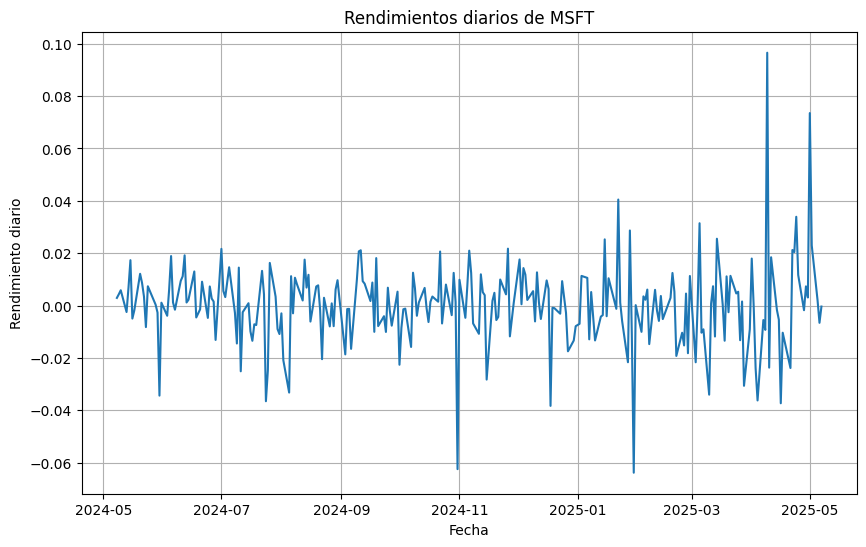

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(daily_returns)
plt.title('Rendimientos diarios de MSFT')
plt.ylabel('Rendimiento diario')
plt.xlabel('Fecha')
plt.grid(True)
plt.show()

In [48]:
volatilidad_anual

np.float64(0.25520004666558554)

In [49]:
volatilidad_diaria

0.016076091858314705

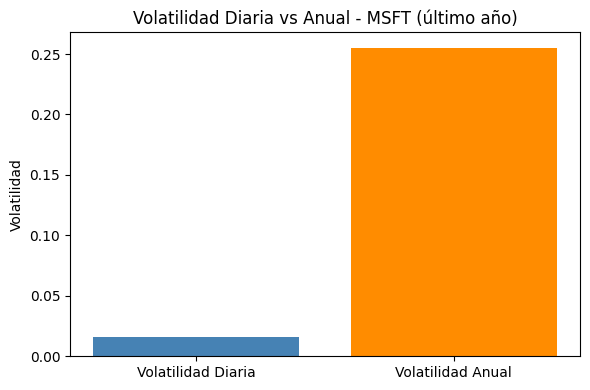

In [50]:
# Gráfica de volatilidades
labels = ['Volatilidad Diaria', 'Volatilidad Anual']
values = [volatilidad_diaria, volatilidad_anual]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['steelblue', 'darkorange'])
plt.title('Volatilidad Diaria vs Anual - MSFT (último año)')
plt.ylabel('Volatilidad')
plt.tight_layout()
plt.show()

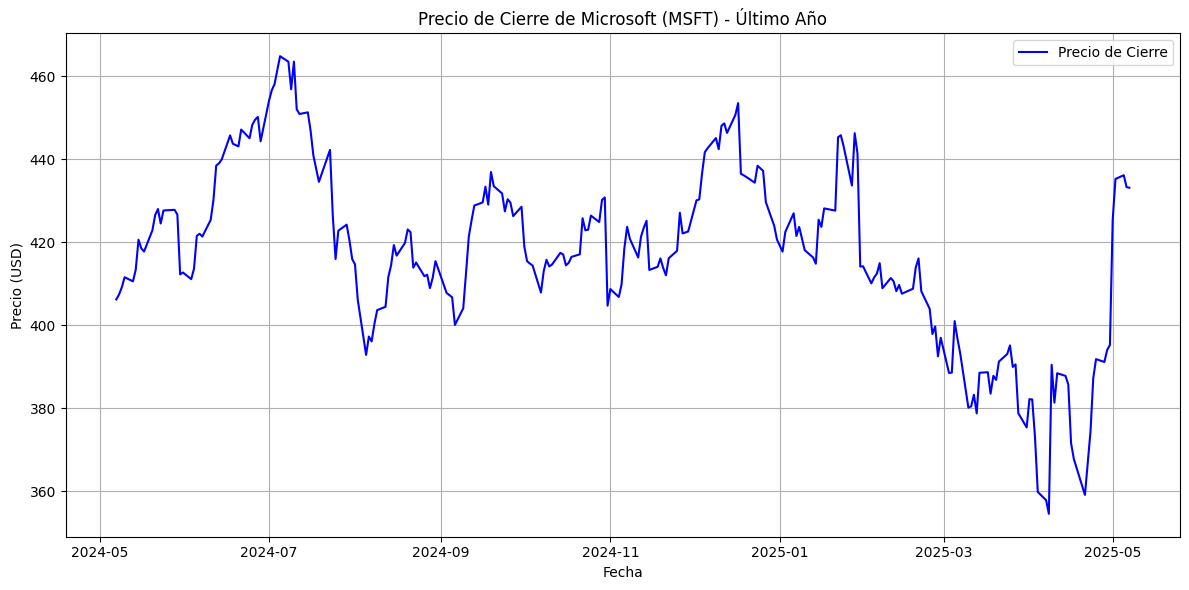

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(hist.index, hist['Close'], label='Precio de Cierre', color='blue')
plt.title('Precio de Cierre de Microsoft (MSFT) - Último Año')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Opción Americana - Árbol Binomial

In [52]:
# Parámetros del Bull Call Spread americana
K1 = round(S0 * 0.95, 2)  # Strike de la call comprada
K2 = round(S0 * 1.05, 2)  # Strike de la call vendida
T = 1/12              # Tiempo a vencimiento (1 mes)
r = 0.05                  # Tasa libre de riesgo
sigma = volatilidad_anual               # Volatilidad estimada
N = 100                   # Número de pasos en el árbol

In [53]:
def price_american_option_binomial( S, K, T, r, sigma, n, option_type):

    dt = T/n

    # factor de subida
    # u = exp(sigma * sqrt(dt))
    u = np.exp(sigma * np.sqrt(dt))

    # factor de bajada
    # d = 1/u
    d = 1/u

    # q Risk neutral value
    q = (np.exp(r * dt) - d) / (u - d)


    # dos matrices para los arboles
    stock_tree = np.zeros((n+1, n+1))
    option_tree = np.zeros((n+1, n+1))


    # arbol de precios del subyacente
    for i in range(n+1):
        for j in range(i+1):
            # esto construye los exponentes correspondientes
            # ejemplo: S * u^2 * d^3
            stock_tree[j, i] = S * (u ** (i-j)) * (d**j)

        # valores intrínsecos en el vencimiento (ultimo día)
        if option_type == 'call':
            option_tree[:, n] = np.maximum(stock_tree[:, n] - K, 0)
        elif option_type == 'put':
            option_tree[:, n] = np.maximum(K - stock_tree[:, n], 0)


    for i in range(n-1, -1, -1):
        for j in range(i+1):
            option_tree[j, i] = np.exp(-r * dt) * (q * option_tree[j, i+1] + (1-q) * option_tree[j+1, i+1])

            if option_type == 'call':
                option_tree[j, i] = np.maximum(stock_tree[j, i] - K, option_tree[j, i])
            elif option_type == 'put':
                option_tree[j, i] = np.maximum(K - stock_tree[j, i], option_tree[j, i])

    return option_tree[0,0]


In [54]:
# Calcular valor del Bull Call Spread Americano
option_type = 'call'
call_k1 = price_american_option_binomial(S0, K1, T, r, sigma, N, option_type)
call_k2 = price_american_option_binomial(S0, K2, T, r, sigma, N, option_type)
bull_call_spread_americana = call_k1 - call_k2

print(f"Valor Bull Call Spread (Americana): {bull_call_spread_americana:.2f}")

Valor Bull Call Spread (Americana): 21.98


In [55]:
S0 = S0  # Precio spot
K1 = S0 * 0.95     # Strike bajo
K2 = S0 * 1.05    # Strike alto
sigma = volatilidad_anual  # Volatilidad anual estimada
r = 0.05     # Tasa libre de riesgo
T = 1/12       # Tiempo en años
n =  100     # Número de pasos binomiales


In [56]:
K1

np.float64(411.4924942016601)

In [57]:
K2

np.float64(454.8074935913086)

In [58]:
# BULL SPREAD ESTRATEGIA
net_premium = call_k1 - call_k2 #diferencia entre la prima de la opción comprada y la opción vendida
max_gain = (K2 - K1) - net_premium #MAXIMA GANANCIA
max_loss = net_premium #MAXIMA PERDIDA
breakeven = K1 + net_premium #PUNTO DE EQUILIBRIO (NI GANAS NI PIERDES)

In [59]:
# ======= Resultados =======
print("\n Estrategia Bull Spread sobre MSFT: ")
print(f"Precio Spot  usado (S0): ${S0:.2f}")
print(f"Strike bajo (K1): ${K1}, Prima Call comprada: ${call_k1:.2f}")
print(f"Strike alto (K2): ${K2}, Prima Call vendida: ${call_k2:.2f}")
print(f"Costo neto inicial (prima neta): ${net_premium:.2f}")
print(f"Ganancia máxima: ${max_gain:.2f}")
print(f"Pérdida máxima: ${max_loss:.2f}")
print(f"Break-even (punto equilibrio): ${breakeven:.2f}")


 Estrategia Bull Spread sobre MSFT: 
Precio Spot  usado (S0): $433.15
Strike bajo (K1): $411.4924942016601, Prima Call comprada: $27.44
Strike alto (K2): $454.8074935913086, Prima Call vendida: $5.46
Costo neto inicial (prima neta): $21.98
Ganancia máxima: $21.34
Pérdida máxima: $21.98
Break-even (punto equilibrio): $433.47


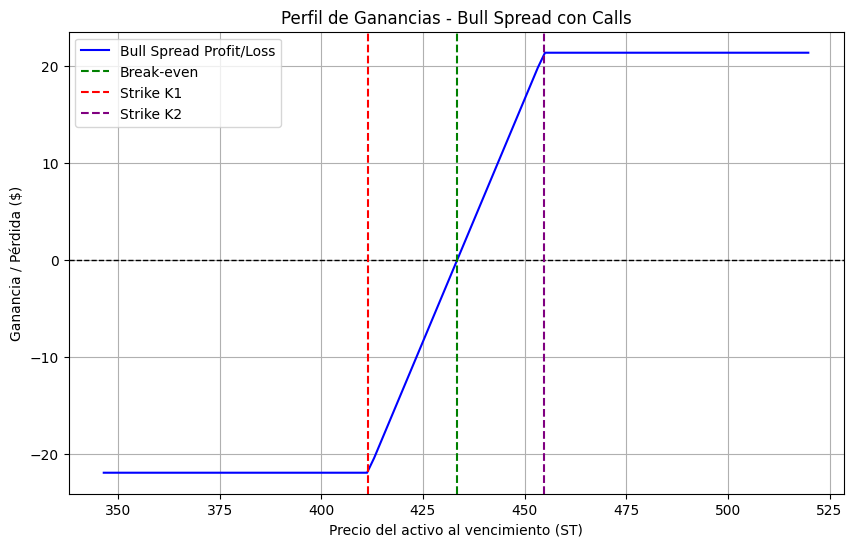

In [61]:

precios_finales = np.linspace(S0 * 0.8, S0 * 1.2, 100)
ganancias = []

for ST in precios_finales:
    # Call comprada en K1
    payoff_call_K1 = max(ST - K1, 0)
    # Call vendida en K2
    payoff_call_K2 = max(ST - K2, 0)
    ganancia = (payoff_call_K1 - payoff_call_K2) - net_premium
    ganancias.append(ganancia)

plt.figure(figsize=(10, 6))
plt.plot(precios_finales, ganancias, label='Bull Spread Profit/Loss', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(breakeven, color='green', linestyle='--', label='Break-even')
plt.axvline(K1, color='red', linestyle='--', label='Strike K1')
plt.axvline(K2, color='purple', linestyle='--', label='Strike K2')

plt.title('Perfil de Ganancias - Bull Spread con Calls')
plt.xlabel('Precio del activo al vencimiento (ST)')
plt.ylabel('Ganancia / Pérdida ($)')
plt.legend()
plt.grid(True)
plt.show()


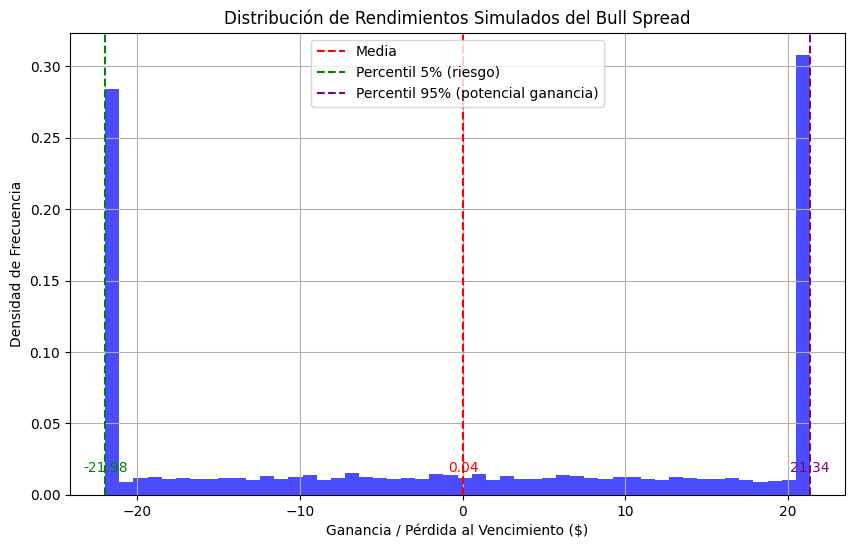

In [62]:
# Simulación de precios de cierre
np.random.seed(42)
num_simulaciones = 10000
precios_simulados = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.randn(num_simulaciones))

payoff_call_K1 = np.maximum(precios_simulados - K1, 0)
payoff_call_K2 = np.maximum(precios_simulados - K2, 0)
ganancias_simuladas = payoff_call_K1 - payoff_call_K2 - net_premium

media = np.mean(ganancias_simuladas)
p5 = np.percentile(ganancias_simuladas, 5)
p95 = np.percentile(ganancias_simuladas, 95)

plt.figure(figsize=(10, 6))
plt.hist(ganancias_simuladas, bins=50, density=True, color='blue', alpha=0.7)
plt.axvline(media, color='red', linestyle='--', label='Media')
plt.axvline(p5, color='green', linestyle='--', label='Percentil 5% (riesgo)')
plt.axvline(p95, color='purple', linestyle='--', label='Percentil 95% (potencial ganancia)')

plt.text(media, plt.ylim()[1]*0.05, f'{media:.2f}', color='red', ha='center')
plt.text(p5, plt.ylim()[1]*0.05, f'{p5:.2f}', color='green', ha='center')
plt.text(p95, plt.ylim()[1]*0.05, f'{p95:.2f}', color='purple', ha='center')

plt.title('Distribución de Rendimientos Simulados del Bull Spread')
plt.xlabel('Ganancia / Pérdida al Vencimiento ($)')
plt.ylabel('Densidad de Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

La distribución de rendimientos simulados del Bull Call Spread muestra una forma bimodal y simétrica, con altas probabilidades de resultados extremos en ambos lados (ganancias de ±20 dólares). Esto refleja la sensibilidad de la estrategia a los movimientos bruscos del subyacente, donde las ganancias y pérdidas están limitadas pero se concentran en valores extremos. La frecuencia baja en los valores intermedios sugiere que los resultados moderados son menos probables.

Lo que buscamos con esta gráfica es visualizar la distribución de los rendimientos esperados del Bull Spread bajo distintas condiciones de mercado. Utilizando simulaciones de Monte Carlo, generamos múltiples escenarios posibles del precio del activo subyacente al vencimiento, lo que nos permite evaluar la frecuencia y probabilidad de obtener ciertos niveles de ganancia o pérdida.

La forma de la distribución revela que la estrategia tiende a alcanzar sus valores máximos y mínimos con mayor frecuencia, lo que indica que los resultados extremos son comunes, mientras que los valores intermedios ocurren menos. A través de la línea de la media y los percentiles del 5% y 95%, identificamos el rendimiento promedio y los límites de los escenarios más favorables y desfavorables.

### Comparación de diferentes precios strike usando simulación Monte Carlo

In [63]:
# Obtener datos de opciones de Microsoft
ticker = yf.Ticker("MSFT")
option_dates = ticker.options
first_expiry = option_dates[0]
option_chain = ticker.option_chain(first_expiry)

# Obtener strikes disponibles
call_strikes = option_chain.calls['strike'].tolist()
current_price = ticker.history(period="1d")['Close'][0]

# Filtrar strikes alrededor del precio actual
relevant_strikes = [s for s in call_strikes if current_price - 40 <= s <= current_price + 40]

# Generar pares de strikes con diferencia de 20 o 30
strike_pairs = []
for i in range(len(relevant_strikes)):
    for j in range(i + 1, len(relevant_strikes)):
        diff = relevant_strikes[j] - relevant_strikes[i]
        if diff in [20, 30]:
            strike_pairs.append((relevant_strikes[i], relevant_strikes[j]))
        if len(strike_pairs) >= 5:
            break
    if len(strike_pairs) >= 5:
        break

print("Strike pairs sugeridos:", strike_pairs)


Strike pairs sugeridos: [(395.0, 415.0), (395.0, 425.0), (397.5, 417.5), (397.5, 427.5), (400.0, 420.0)]


<ipython-input-63-9bf8df5dd394>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = ticker.history(period="1d")['Close'][0]


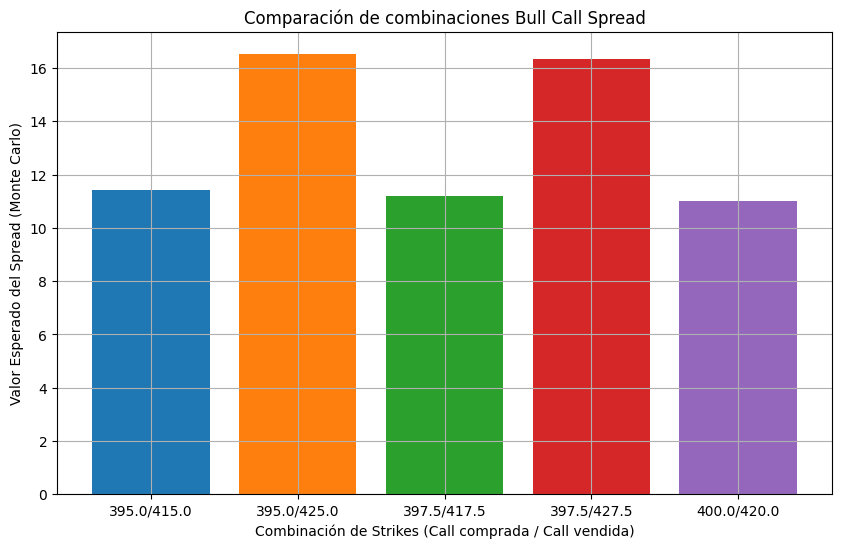

In [64]:
np.random.seed(0)

strike_pairs = [(395.0, 415.0), (395.0, 425.0), (397.5, 417.5), (397.5, 427.5), (400.0, 420.0)]
results = []

r = 0.05  # tasa libre de riesgo
T = 1     # tiempo en años
sigma = 0.3
N = 10000
dt = T
S0 = 433

for K1_, K2_ in strike_pairs:
    Z = np.random.normal(0, 1, N)
    Z_anti = -Z

    ST = S0 * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    ST_anti = S0 * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_anti)

    payoff = np.maximum(ST - K1_, 0) - np.maximum(ST - K2_, 0)
    payoff_anti = np.maximum(ST_anti - K1_, 0) - np.maximum(ST_anti - K2_, 0)

    discounted_payoff = np.exp(-r * T) * 0.5 * (payoff + payoff_anti)
    value = np.mean(discounted_payoff)

    results.append((K1_, K2_, value))

# Convertimos a DataFrame para visualizar
df_results = pd.DataFrame(results, columns=["Strike Call Comprada", "Strike Call Vendida", "Valor Esperado"])
df_results.sort_values("Valor Esperado", ascending=False, inplace=True)


# Visualización
plt.figure(figsize=(10, 6))
for K1_, K2_, val in results:
    label = f"{K1_}/{K2_}"
    plt.bar(label, val)
plt.xlabel("Combinación de Strikes (Call comprada / Call vendida)")
plt.ylabel("Valor Esperado del Spread (Monte Carlo)")
plt.title("Comparación de combinaciones Bull Call Spread")
plt.grid(True)
plt.show()

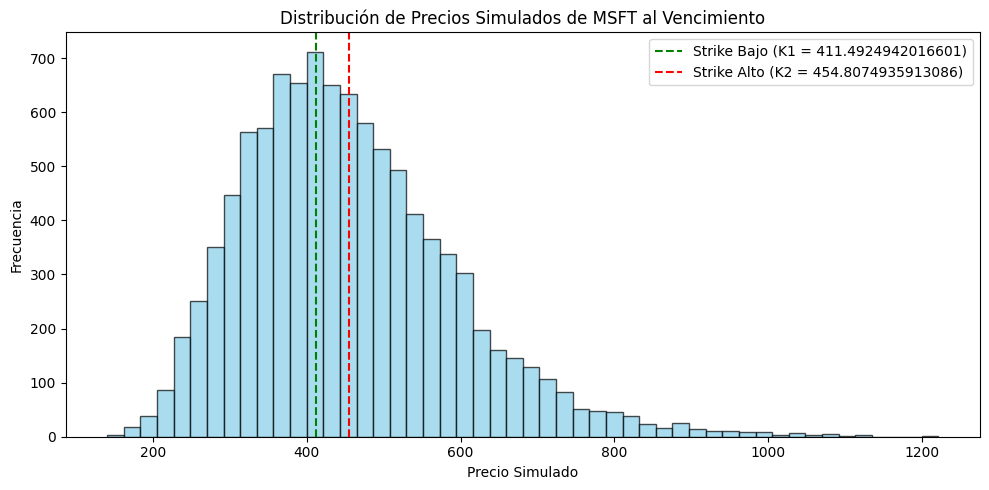

In [65]:
# Payoff del Bull Call Spread
payoff = np.maximum(ST - K1, 0) - np.maximum(ST - K2, 0)

# Gráfica: Precios simulados
plt.figure(figsize=(10, 5))
plt.hist(ST, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(K1, color='green', linestyle='--', label=f'Strike Bajo (K1 = {K1})')
plt.axvline(K2, color='red', linestyle='--', label=f'Strike Alto (K2 = {K2})')
plt.title('Distribución de Precios Simulados de MSFT al Vencimiento')
plt.xlabel('Precio Simulado')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()



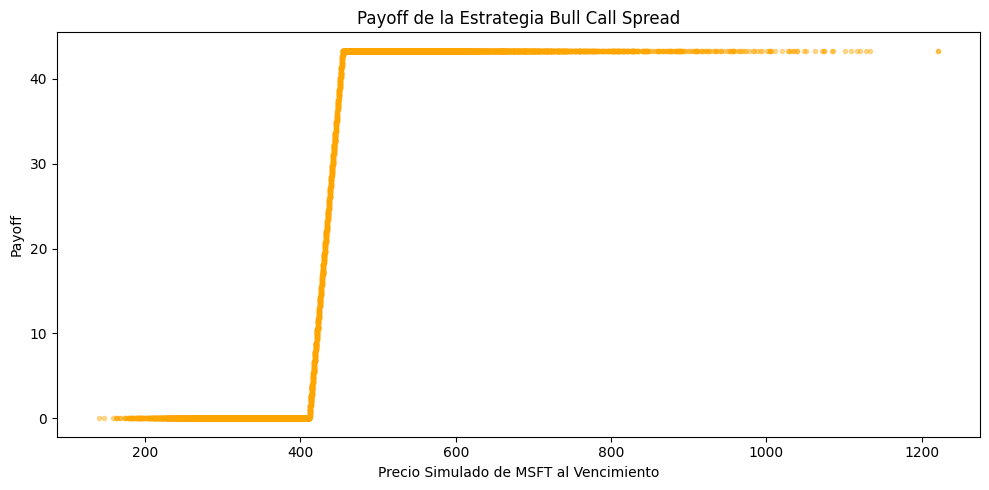

In [66]:
# Gráfica de Payoff del Bull Spread
plt.figure(figsize=(10, 5))
plt.plot(ST, payoff, '.', alpha=0.4, color='orange')
plt.title('Payoff de la Estrategia Bull Call Spread')
plt.xlabel('Precio Simulado de MSFT al Vencimiento')
plt.ylabel('Payoff')
plt.tight_layout()
plt.show()

# Simulación para distintos strikes
strike_range = np.arange(420, 470, 5)
results = []

for K1_sim in strike_range:
    for K2_sim in strike_range:
        if K1_sim < K2_sim:
            payoff_sim = np.maximum(ST - K1_sim, 0) - np.maximum(ST - K2_sim, 0)
            results.append((K1_sim, K2_sim, np.mean(payoff_sim)))

# Crear DataFrame de resultados
df_results = pd.DataFrame(results, columns=['K1', 'K2', 'Expected_Payoff'])

# Pivot para el mapa
pivot_table = df_results.pivot(index='K1', columns='K2', values='Expected_Payoff')



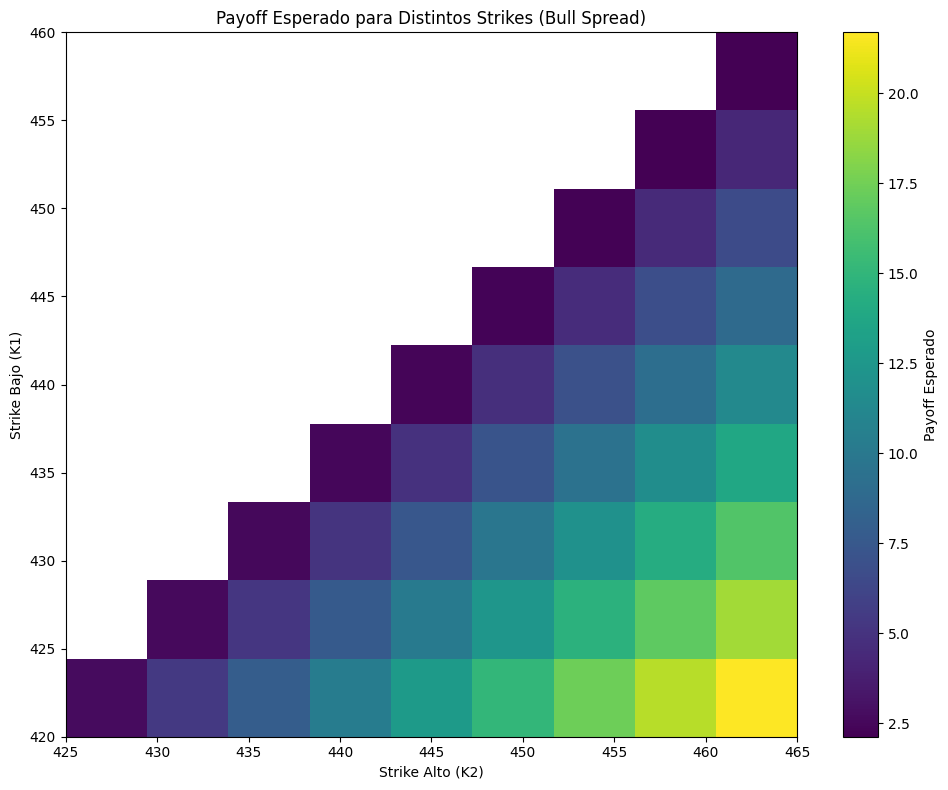

In [67]:
# Gráfica de payoff esperado
plt.figure(figsize=(10, 8))
plt.imshow(pivot_table, origin='lower', cmap='viridis', aspect='auto',
           extent=[pivot_table.columns.min(), pivot_table.columns.max(),
                   pivot_table.index.min(), pivot_table.index.max()])
plt.colorbar(label='Payoff Esperado')
plt.title('Payoff Esperado para Distintos Strikes (Bull Spread)')
plt.xlabel('Strike Alto (K2)')
plt.ylabel('Strike Bajo (K1)')
plt.tight_layout()
plt.show()